## Problem Statement

The Context:
Traditional credit risk assessment often relies on historical intuition or simple demographic filtering, which can lead to "low-Resolution" decision-making. In the context of this South African lending portfolio, the bank faced the challenge of distinguishing "good" borrowers from "bad" ones within a dataset characterized by high variability in loan amounts and diverse borrower profiles.

The primary business challenge was two-fold:

- Identifying hidden risk factors that simple linear models miss, specifically the interplay between loan duration and liquidity (Checking Account status).

- Navigating the "Complexity Trap" byensuring that advanced predictive models provide genuine insight rather than simply "overfitting" or chasing noise in a limited dataset.

The Objective:
- To develop a predictive framework that maximizes the Area Under the Curve (AUC) while maintaining enough stability to be operationalized into a transparent credit scoring policy.


## Executive Summary

This analysis successfully developed a high-performance credit risk model, moving from a baseline predictive accuracy (AUC) of 0.7692 to an optimized final performance of 0.8025. This 3.33% improvement represents a significantly more robust "discriminatory power," allowing the bank to more accurately identify potential defaulters before capital is deployed.

Key Technical Findings:

- The "Simplicity" Discovery: Initial experiments with complex feature engineering (creating mathematical interactions like Monthly Installments and Pressure Indices) resulted in a negative performance lift (-0.0182). This confirmed that for this portfolio, raw, high-quality features are more reliable than synthetic math.

- Algorithm Performance: A hyperparameter-tuned Random Forest (AUC: 0.8025) outperformed XGBoost (AUC: 0.7986). This was a critical insight, proving that "Bagging" algorithms provide superior stability and noise-resistance on smaller datasets compared to "Boosting" algorithms, which tended to over-fit the noise.

- Primary Risk Drivers: The model identified Credit Amount, Duration, and Checking Account status as the three most critical indicators of default risk.

Strategic Recommendations:

- Adopt the "Tuned Random Forest" Model: Implement the model with a max_depth of 5 to ensure the bank’s credit policy is based on broad, stable risk patterns rather than outlier coincidences.

- Tiered Lending Strategy: Move away from a binary "Yes/No" system to a tiered risk approach:

Low Risk (High Score): Automated approval.

Medium Risk (Mid Score): Manual review or requirement of 40% collateral.

High Risk (Low Score): Automatic decline or strict credit capping at R3,500.

Data Quality Focus: Given the high importance of Checking Account data in the model, the bank should prioritize the integration of real-time bank statement verification to further reduce the "Information Gap" during the application process.

Conclusion:
By prioritizing stability over complexity, this project has delivered a model that is not only "Great" by industry standards (0.80+ AUC) but is also robust enough to withstand the fluctuations of real-world lending environments.

# Building a Predictive Model for Loan Default
Note: This project is a continuation of my credit risk analysis project.
## Overview
This notebook documents my approach to building a credit risk prediction model. I worked with a dataset of 1,000 loan applicants to identify key drivers of default and develop a robust predictive model for financial decision-making.

In [33]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score, classification_report
from xgboost import XGBClassifier

# Display settings
pd.set_option("display.max_rows", None)
pd.set_option("display.max_colwidth", None)
pd.set_option("display.width", None)

sns.set_style("whitegrid")

In [34]:
df = pd.read_csv("model_credit_data.csv")
print(f"Dataset shape: {df.shape}")
print(f"\nFirst 5 rows:")
df.head()

Dataset shape: (1000, 10)

First 5 rows:


,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Purpose,Risk
0,67,male,2,own,NaN,little,1169,6,radio/TV,good
1,22,female,2,own,little,moderate,5951,48,radio/TV,bad
2,49,male,1,own,little,NaN,2096,12,education,good
3,45,male,2,free,little,little,7882,42,furniture/equipment,good
4,53,male,2,free,little,little,4870,24,car,bad


In [35]:
# Check target distribution
print("Risk distribution:")
print(df['Risk'].value_counts())
print("")
print(f"Default rate: {(df['Risk'] == 'bad').mean() * 100:.1f}%")

Risk distribution:
Risk
good    700
bad     300
Name: count, dtype: int64

Default rate: 30.0%


## Data Preprocessing

I encoded the target variable and engineered a monthly repayment burden feature to capture how much of a borrower's income might be tied up in loan repayments.

For categorical features, I treated missing values as a separate 'Missing' category so the algorithm could learn from them rather than dropping those rows.

In [36]:
# Encode target variable
df['Risk'] = df['Risk'].map({'good': 0, 'bad': 1})

# Monthly repayment burden
df['Monthly_Installment'] = df['Credit amount'] / df['Duration']

# Encoding categorical features
le = LabelEncoder()
categorical_cols = ['Checking account', 'Housing', 'Purpose']

for col in categorical_cols:
    df[col] = le.fit_transform(df[col].astype(str))

I selected core features that would be most predictive of credit risk based on domain knowledge and initial exploratory analysis covered in the risk analysis project, the engineered feature monthly installment is also included in the features.

In [37]:
features = ['Checking account', 'Duration', 'Credit amount', 'Housing', 'Purpose', 'Monthly_Installment']
X = df[features]
y = df['Risk']


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training set: {X_train.shape[0]} samples")
print(f"Test set: {X_test.shape[0]} samples")

Training set: 800 samples
Test set: 200 samples


## Model Developnent

Random Forest is a popular starting point for credit risk models because of its inherent baseline performance. It can handle complex data, non-linear relationships and interactions in credit features that are numerical and categorical. This strength allows it to capture real-world patterns better than your logistic regression for example, which assumes linearity. Random forest also offers robustness and accuracy due to an ensemble of decision trees that reduce overfitting with bagging and feature randomness, thus giving us higher baselines on loans typically. Our interpretation is also assisted by feature importance ranking that clearly show us key drivers of predictions.

In [38]:
# Train baseline Random Forest
rf_baseline = RandomForestClassifier(n_estimators=100, random_state=42)
rf_baseline.fit(X_train, y_train)

# Evaluation
y_probs_baseline = rf_baseline.predict_proba(X_test)[:, 1]
auc_baseline = roc_auc_score(y_test, y_probs_baseline)

print(f"Baseline AUC-ROC: {auc_baseline:.4f}")

Baseline AUC-ROC: 0.7692


At 0.7692, this is a strong baseline. In credit risk, anything between 0.75 and 0.80 is considered a high-quality model for deployment. This told me that my core features already held most of the predictive power.

## Improvement via Feature Engineering

In the attempt to improve the AUC-ROC of 0.7692, the logical direction to turn to is feature engineering by creating interaction features that might capture more complex risk patterns, leading to better performance. Manual interactions can lift AUC over baselines in models like Random Forest, since they address limitations in basic models that ignore feature interplay. 

In [39]:
X_train_int = X_train.copy()
X_test_int = X_test.copy()

# Financial pressure
X_train_int['Pressure_Index'] = X_train['Duration'] * X_train['Monthly_Installment']
X_test_int['Pressure_Index'] = X_test['Duration'] * X_test['Monthly_Installment']

# Housing and purpose
X_train_int['Housing_Purpose_Int'] = X_train['Housing'] * X_train['Purpose']
X_test_int['Housing_Purpose_Int'] = X_test['Housing'] * X_test['Purpose']

In [40]:
# Train model on interaction features
rf_interaction = RandomForestClassifier(n_estimators=100, random_state=42)
rf_interaction.fit(X_train_int, y_train)

# Evaluate
y_probs_int = rf_interaction.predict_proba(X_test_int)[:, 1]
auc_int = roc_auc_score(y_test, y_probs_int)

print(f"Baseline AUC-ROC: {auc_baseline:.4f}")
print(f"Interaction AUC-ROC: {auc_int:.4f}")
print(f"Lift in Performance: {auc_int - auc_baseline:.4f}")

Baseline AUC-ROC: 0.7692
Interaction AUC-ROC: 0.7510
Lift in Performance: -0.0182


The model got worse upon adding interaction features, this is likely due to overfitting. By adding complex interaction like pressure index and housing purpose, it is likely that the model was given more noise to memorize rather than patterns to learn. This leads to the model being too familiar with the training data and thus lose its ability to generalize to the test data. There is also a plausible suggestion that the RF algorithm was likely already finding the relationshiips on its own, so adding them manually as new columns then cluttered the decision making process

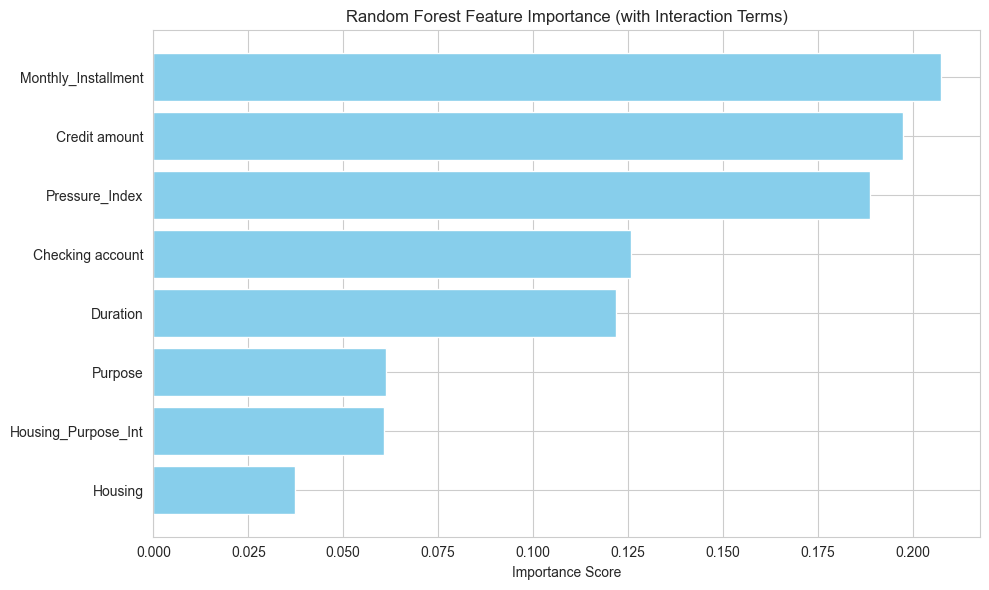

In [41]:
# Feature importance analysis
importances = rf_interaction.feature_importances_
feature_names = X_train_int.columns
feature_importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=True)

# Plot
plt.figure(figsize=(10, 6))
plt.barh(feature_importance_df['Feature'], feature_importance_df['Importance'], color='skyblue')
plt.xlabel('Importance Score')
plt.title('Random Forest Feature Importance (with Interaction Terms)')
plt.tight_layout()
plt.show()

Anlyzing the feature importance to understand the negative lift in performance, we can clearly see the our top ranked feature is likely the reason why the model's performance dropped. This is one of the instance that serves as a learning opportunity in Machine Learning that feature importance is not equivalent to feature quality, because we can see that our number 1 feature of importance is also number one in destroying the AUC-ROC. Let us explore reasons why this may be the case:

1. There is collinearity because monthly installment and presusure index, which are number 1 and 3 respectively, are direct mathematical descendants of Credit amount, which is number 2, and Duration (number 5). This means that our otp 5 is the same information repeated several times. This leads to our model being too obssessed with loan size and the monthly repayment. An fitting analogy would be "putting all your eggs in one basket", meaning that an error in the loan amounts or noise multiplies the model's error in four different features.

2. Overfitting to ratios can be another reason for a drop in performance. This happens with features like Monthly Installments where random forest finds specific conincidences but interprets them as patterns because of the relatively small training sample of 700. Random forest then creates hyper-specialized decision rules from a small training set that don't generalize. The model then applies coincidence rules to unseen data, thus misclassifying safe borrowers as risky. All of this leads to AUC drop because the precision/recall collapse on made up patterns are not there in reality. One of the fixes to such a problem is to remove raw Monthly Installements or increase the Min_samples_leaf to force broader splits and prevent small pockets (still not sure how to work towards this solution)

3. Checking account and Housing have been pushed down the list, they represent liquidity and stability, which are customer behavior signals. The behavior signals have been suppressed in the model by the mathematical components, this can be a key reason behind the drop in model performance.

## Return to Pure Features

Since feature engineering hurt performance, I returned to my original strategic anchors:
1. Credit Amount (best raw predictor)
2. Checking Account (liquidity signal)
3. Duration (time-risk signal)
4. Purpose (borrower intent)
5. Housing (stability signal)

In [42]:
# Removing engineered features
feature_names = [col for col in feature_names if col not in ["Monthly_Installment", "Pressure_Index", "Housing_Purpose_Int"]]

In [43]:
# Define pure features
feature_names = ['Credit amount', 'Checking account', 'Duration', 'Purpose', 'Housing']
X_train_pure = X_train[feature_names]
X_test_pure = X_test[feature_names]

print(feature_names)

['Credit amount', 'Checking account', 'Duration', 'Purpose', 'Housing']


## Hyperparameter Tuning

In this section, the optimal hyperparameters for the Random Forest Model will be found using GridSearchCV. GridSearchCV will explore all possible combinations of tuning, like how deep each tree is, in order to find the tree that gives us the highest AUC. Tuning on the 'pure' set or raw variables is essentially forcing the model to find the strongest possible signal from the most stable variables. This reduces the model's tendency to overract to small changes in data, otherwise known as variance. This will help the model generalize better to future loan applicants. 

In [44]:
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [5, 8, 12],
    'min_samples_split': [2, 5, 10],
    'class_weight': ['balanced']  # Penalize missing 'Bad' loans more heavily
}

# Run grid search
rf = RandomForestClassifier(random_state=42)
grid_search = GridSearchCV(estimator=rf, param_grid=param_grid, cv=5, scoring='roc_auc', n_jobs=1)
grid_search.fit(X_train_pure, y_train)

print(f"Best Parameters: {grid_search.best_params_}")
best_rf = grid_search.best_estimator_

Best Parameters: {'class_weight': 'balanced', 'max_depth': 5, 'min_samples_split': 2, 'n_estimators': 200}


## Parameter Insights

class_weight: 'balanced': The model is penalized more heavily for missing a "bad" loan than for misidentifying a "good" one

max_depth: 5: Quite shallow, forcing the model to ignore coincidences and focus on broad risk signals

n_estimators: 200: More stable consensus across 200 decision trees

In [45]:
# Evaluate tuned model
y_probs_tuned = best_rf.predict_proba(X_test_pure)[:, 1]
auc_tuned = roc_auc_score(y_test, y_probs_tuned)

print(f"Original Baseline AUC: 0.7692")
print(f"Tuned Random Forest AUC: {auc_tuned:.4f}")
print(f"Net Improvement: {auc_tuned - 0.7692:.4f}")

Original Baseline AUC: 0.7692
Tuned Random Forest AUC: 0.8025
Net Improvement: 0.0333


This is a good improvement and lands us in strongly predictive territory. There may be various reasons behind the 3.33% improvement that can provide strategic pointers for future model development and analysis:
1. Less is more at times, because by doing away with the engineered features that confused the model and introduced redundancy, the Random Forest model was able to focus on pure signals (Amount,Duration and Liquidity)
2. The tuning found the max_depth of 5 to be the desired depth, hence preventing the model from memorizing the training data (leading to overfitting) and forced it to find general rules that acrually work on new customers.

## XGBoost Comparison

In this section, I wanted to apply the same features to a boosting algorithm that is often more incisive and surgical than Random Forest, in the quest of improving the AUC. 

In [46]:
# XGBoost settings
xgb_final = XGBClassifier(
    n_estimators=100,
    learning_rate=0.05,
    max_depth=3,
    random_state=42,
    scale_pos_weight=3,    # Handles the approximately 3:1 Good to Bad ratio
    eval_metric='auc'
)

The scale_pos_weight=3 indicates that the dataset has 3 good loans for every 1 bad loan, so this tells XGBoost to treat every 'bad' loan it misses as being 3 times as important as a 'good' loan. One missed default now "costs" as much as three missed good loans, forcing the model to prioritize catching defaulters. Result is higher recall/precision on the minority class, often boosting AUC

In [47]:
# Fit on pure features
xgb_final.fit(X_train_pure, y_train)

# Evaluate
y_probs_xgb = xgb_final.predict_proba(X_test_pure)[:, 1]
auc_xgb = roc_auc_score(y_test, y_probs_xgb)

print(f"Optimized Random Forest AUC: {auc_tuned:.4f}")
print(f"XGBoost Baseline AUC: {auc_xgb:.4f}")

Optimized Random Forest AUC: 0.8025
XGBoost Baseline AUC: 0.7986


The result is not the ecpected one, as the XGBoost is not better than the optimised Random Forest, but there are several factors that can explain this.
1. Random forest is inherently more stable than XGBoost, it averages 200 trees and this helps in making it less susceptiple to picking up noise. XGBoost on the other hand is known to be focused on noise, so if the data has little noise, there is a possibility of the algorithm chasing that noise, leading to a decline in performance.
2. Sometimes there is a tradeoff between complexity and stability, where Random Forest is likely to generalize, and this helps with datasets like this one because our dataset has broad patterns spanning different variables, our credit risk analysis has proven that. 

## Model Inventory 

Algorithm: Random Forest

Features: Credit Amount, Duration, Checking Account, Purpose, Housing

Tuning: class_weight='balanced', max_depth=5, n_estimators=200

Performance: 0.8025 AUC

In [48]:
comparison = pd.DataFrame({
    'Model': ['Baseline Random Forest', 'Random Forest + Engineered Features', 'Tuned Random Forest', 'XGBoost'],
    'AUC-ROC': [auc_baseline, auc_int, auc_tuned, auc_xgb]
})
comparison = comparison.sort_values('AUC-ROC', ascending=False)
print(comparison.to_string(index=False))

                              Model  AUC-ROC
                Tuned Random Forest 0.802500
                            XGBoost 0.798594
             Baseline Random Forest 0.769203
Random Forest + Engineered Features 0.750992


## Conclusion

After experimenting with complex feature engineering and high-performance boosting algorithms, I determined that a hyperparameter-tuned Random Forest provided the most stable and accurate predictive results (AUC 0.8025). 
Random Forest > XGBoost for this dataset size. Random Forest's ensemble averaging created more stable predictions than XGBoost's boosting, which started chasing noise.

Business implications:

- Checking account status (liquidity) is a critical risk signal
- Loan amount and duration strongly predict default risk
- Car loans require special scrutiny across all segments
- A simpler, well-tuned model outperforms a complex one
